# Modelling v1 — EKF + Newton Raphson vs Linear Regression
Implementasi sesuai paper: Fahmy et al. (2025)

Pipeline:
1. EKF berjalan per-cycle tracking degradasi kapasitas (QDischarge)
2. Newton Raphson mencari cycle ke berapa kapasitas menyentuh EOL threshold
3. Dibandingkan dengan Linear Regression ElasticNet sebagai baseline

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [2]:
from config_v1 import (
    OUTPUT_DIR, EKF_P0, EKF_R, EKF_Q,
    BATTERY_Q_NOMINAL, BATTERY_RO, BATTERY_R, BATTERY_C,
    SAMPLING_TIME,
    NR_TOL, NR_MAX_ITER
)

## 1. Load Preprocessed Data

In [3]:
with open(os.path.join(OUTPUT_DIR, 'preprocessed_v1.pkl'), 'rb') as f:
    data = pickle.load(f)

train_cells = data['train']
val_cells   = data['val']
test_cells  = data['test']

print(f'Train: {len(train_cells)} | Val: {len(val_cells)} | Test: {len(test_cells)}')

Train: 45 | Val: 43 | Test: 45


## 2. EKF — Tracking Degradasi Kapasitas per Cycle

EKF berjalan di level cycle (bukan timestep).
State: x = [Q_k, dQ_k] = [kapasitas cycle k, laju degradasi]
Measurement: QDischarge dari summary data
Output: smoothed capacity curve per cell

Parameter dari Table 2 paper: P0=[2,0], R=0.01, Q=[0.8,0.2]

In [4]:
def run_ekf(cell, ekf_params):
    """
    EKF per timestep sesuai paper Fig 3 dan eq 3-24.
    State: x = [x1, x2] = [cycle_life, discharge_voltage]
    Input per timestep: V, I
    x1 diupdate per cycle (cycle counter), x2 diestimasi per timestep
    Output: initial guess cycle life untuk Newton Raphson
    """
    Q_nom = ekf_params['Q_nom']
    R_bat = ekf_params['R_bat']
    C_bat = ekf_params['C_bat']
    Ro    = ekf_params['Ro']
    ts    = ekf_params['ts']

    P0 = np.diag(ekf_params['P0'])
    Rw = np.diag(ekf_params['Rw'])
    Rv = np.array([[ekf_params['Rv']]])

    # Matriks sistem sesuai eq 9-12
    Ak = np.array([[0,           0        ],
                   [0, -1/(R_bat*C_bat)   ]])
    Bk = np.array([[1/Q_nom],
                   [1/C_bat]])
    Ck = np.array([[1, 1]])
    Dk = np.array([[Ro]])

    # Diskritisasi eq 13-18
    Ad = np.eye(2) + ts * Ak
    Bd = ts * Bk
    Cd = Ck
    Dd = Dk

    cycles     = cell['cycles']
    n_cycles   = len(cycles)
    Q_discharge = cell['summary']['QDischarge']

    # Init state: x1=0 (belum ada cycle), x2=V awal cycle pertama
    if len(cycles) == 0:
        return np.nan

    V0 = cycles[0]['V']
    x  = np.array([0.0, V0[0] if len(V0) > 0 else 3.3])
    P  = P0.copy()

    x1_per_cycle = []  # estimasi cycle life di akhir tiap cycle

    for c_idx, cycle_data in enumerate(cycles):
        V = cycle_data['V']
        I = cycle_data['I']
        n = len(V)

        if n < 5:
            continue

        # Update x1 = cycle counter yang sedang berjalan
        x[0] = float(c_idx + 1)

        for k in range(n):
            u      = I[k]
            y_meas = V[k]

            # Predict eq 19-20
            x_pred = Ad @ x + Bd.flatten() * u
            P_pred = Ad @ P @ Ad.T + Rw

            # Kalman gain eq 21
            S = Cd @ P_pred @ Cd.T + Rv
            K = P_pred @ Cd.T / S[0, 0]

            # Innovation eq 22
            y_hat = (Cd @ x_pred)[0] + Dd[0, 0] * u
            innov = y_meas - y_hat

            # Update eq 22-23
            x = x_pred + K.flatten() * innov
            P = (np.eye(2) - K @ Cd) @ P_pred

        # Akhir cycle: simpan x1 sebagai estimasi cycle life saat ini
        x1_per_cycle.append(x[0])

    if len(x1_per_cycle) < 10:
        return np.nan

    # x1 per cycle seharusnya naik linear (= nomor cycle)
    # tapi karena ada noise EKF, ada deviasi kecil
    # rata-rata x1 di akhir = initial guess cycle life
    # NR akan refine ini ke titik EOL
    return np.array(x1_per_cycle)

## 3. Newton Raphson — Prediksi Cycle EOL

Setelah EKF menghasilkan smoothed capacity curve,
fit model degradasi linear ke trend tersebut.
NR mencari root dari f(x) = Q_model(x) - EOL_threshold = 0
dimana x adalah cycle number → predicted cycle life.

In [5]:
def fit_degradation_model(Q_smoothed):
    n = len(Q_smoothed)
    cycles = np.arange(1, n + 1, dtype=float)
    coeffs = np.polyfit(cycles, Q_smoothed, deg=2)
    return coeffs


def newton_raphson_eol(coeffs, eol_threshold, x0, tol=1e-6, max_iter=100):
    a, b, c = coeffs
    def f(x):  return a*x**2 + b*x + c - eol_threshold
    def df(x): return 2*a*x + b

    x = float(x0)
    for _ in range(max_iter):
        dfx = df(x)
        if abs(dfx) < 1e-12:
            break
        x_new = x - f(x) / dfx
        if abs(x_new - x) < tol:
            return max(x_new, 1.0)
        x = x_new
    return max(x, 1.0)


def predict_cycle_life(cell, ekf_params, eol_threshold, tol, max_iter):
    Q = cell['summary']['QDischarge']
    if len(Q) < 10:
        return np.nan

    x1_per_cycle = run_ekf(cell, ekf_params)
    if isinstance(x1_per_cycle, float) and np.isnan(x1_per_cycle):
        return np.nan

    # Initial guess dari panjang observasi, bukan dari x1
    x0_nr = len(Q) * 1.2

    coeffs    = fit_degradation_model(Q)
    predicted = newton_raphson_eol(coeffs, eol_threshold, x0_nr, tol, max_iter)
    predicted = np.clip(predicted, 50, 5000)
    return predicted

## 4. Run EKF + NR pada Test Set

In [6]:
ekf_params = {
    'Q_nom': BATTERY_Q_NOMINAL,  # 1.1
    'R_bat': 0.1,
    'C_bat': 0.1,
    'Ro':    BATTERY_RO,         # 0.017
    'ts':    SAMPLING_TIME,      # 1.0
    'P0':    EKF_P0,             # [2.0, 0.0]
    'Rw':    EKF_Q,              # [0.8, 0.2]
    'Rv':    EKF_R,              # 0.01
}

EOL_THRESHOLD = 0.88  # 80% x 1.1 Ah

actual_ekfnr    = []
predicted_ekfnr = []

for i, cell in enumerate(test_cells):
    pred = predict_cycle_life(
        cell, ekf_params, EOL_THRESHOLD, NR_TOL, NR_MAX_ITER
    )
    actual_ekfnr.append(cell['cycle_life'])
    predicted_ekfnr.append(pred)
    pred_str = f'{pred:.2f}' if not np.isnan(pred) else 'NaN'
    print(f'Cell {i+1:02d} | Actual: {cell["cycle_life"]:6.0f} | Predicted: {pred_str:>10}')

actual_ekfnr    = np.array(actual_ekfnr)
predicted_ekfnr = np.array(predicted_ekfnr)

Cell 01 | Actual:   1051 | Predicted:    1137.06
Cell 02 | Actual:    702 | Predicted:     733.68
Cell 03 | Actual:    651 | Predicted:     696.10
Cell 04 | Actual:    616 | Predicted:     639.49
Cell 05 | Actual:    599 | Predicted:     628.08
Cell 06 | Actual:   1009 | Predicted:    1158.48
Cell 07 | Actual:   1063 | Predicted:    1191.28
Cell 08 | Actual:   1267 | Predicted:    1367.39
Cell 09 | Actual:   1115 | Predicted:    1242.36
Cell 10 | Actual:   1048 | Predicted:    1140.97
Cell 11 | Actual:    828 | Predicted:     932.76
Cell 12 | Actual:    667 | Predicted:     695.62
Cell 13 | Actual:   1836 | Predicted:    2005.09
Cell 14 | Actual:    828 | Predicted:     947.98
Cell 15 | Actual:   1039 | Predicted:    1168.20
Cell 16 | Actual:   1078 | Predicted:    1190.96
Cell 17 | Actual:    817 | Predicted:     899.81
Cell 18 | Actual:    932 | Predicted:    1044.46
Cell 19 | Actual:    816 | Predicted:     896.96
Cell 20 | Actual:    858 | Predicted:     953.18
Cell 21 | Actual:   

## 5. Sanity Check — Plot EKF Smoothing pada 1 Sel

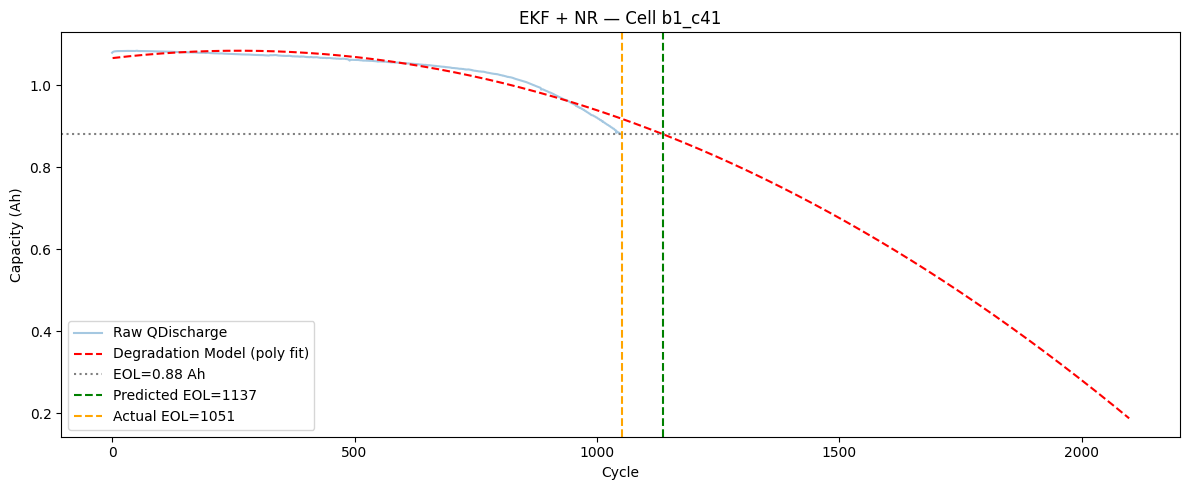

In [7]:
sample    = test_cells[0]
Q_raw     = sample['summary']['QDischarge']
x1_cycles = run_ekf(sample, ekf_params)
coeffs    = fit_degradation_model(Q_raw)

x_range   = np.linspace(1, len(Q_raw) * 2, 500)
Q_model   = np.polyval(coeffs, x_range)
pred_life = predict_cycle_life(sample, ekf_params, EOL_THRESHOLD, NR_TOL, NR_MAX_ITER)

plt.figure(figsize=(12, 5))
plt.plot(Q_raw,   alpha=0.4, label='Raw QDischarge')
plt.plot(x_range, Q_model, 'r--', label='Degradation Model (poly fit)')
plt.axhline(EOL_THRESHOLD, color='gray', linestyle=':', label=f'EOL={EOL_THRESHOLD} Ah')
plt.axvline(pred_life, color='green', linestyle='--', label=f'Predicted EOL={pred_life:.0f}')
plt.axvline(sample['cycle_life'], color='orange', linestyle='--', label=f'Actual EOL={sample["cycle_life"]:.0f}')
plt.xlabel('Cycle')
plt.ylabel('Capacity (Ah)')
plt.title(f'EKF + NR — Cell {sample["cell_id"]}')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Linear Regression Baseline (Elastic Net)

In [8]:
def extract_features(cells):
    feats, targets = [], []
    for cell in cells:
        q  = cell['summary']['QDischarge']
        ir = cell['summary']['IR']
        if len(q) < 100:
            continue
        feats.append([
            np.mean(q[1:101]),
            np.min(q[1:101]),
            np.var(q[1:101]),
            q[99] - q[9],
            np.mean(ir[1:101]),
            np.log(np.var(q[1:101]) + 1e-10),
        ])
        targets.append(cell['cycle_life'])
    return np.array(feats), np.array(targets)


X_train, y_train = extract_features(train_cells)
X_val,   y_val   = extract_features(val_cells)
X_test,  y_test  = extract_features(test_cells)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

lr_model = ElasticNetCV(cv=5, max_iter=10000, random_state=42)
lr_model.fit(np.vstack([X_train, X_val]), np.concatenate([y_train, y_val]))

predicted_lr = lr_model.predict(X_test)
actual_lr    = y_test
print(f'ElasticNet alpha={lr_model.alpha_:.4f}, l1_ratio={lr_model.l1_ratio_:.4f}')

ElasticNet alpha=2.3643, l1_ratio=0.5000


## 7. Evaluasi — RMSE & Average Percentage Error

In [9]:
def rmse(actual, predicted):
    mask = ~np.isnan(predicted)
    return np.sqrt(np.mean((actual[mask] - predicted[mask]) ** 2))

def avg_pct_error(actual, predicted):
    mask = ~np.isnan(predicted)
    return np.mean(np.abs(actual[mask] - predicted[mask]) / actual[mask]) * 100


rmse_ekfnr = rmse(actual_ekfnr, predicted_ekfnr)
ape_ekfnr  = avg_pct_error(actual_ekfnr, predicted_ekfnr)
rmse_lr    = rmse(actual_lr, predicted_lr)
ape_lr     = avg_pct_error(actual_lr, predicted_lr)

print('=' * 57)
print(f'{"Method":<32} {"RMSE":>10} {"Avg%Err":>10}')
print('=' * 57)
print(f'{"EKF + Newton Raphson":<32} {rmse_ekfnr:>10.4f} {ape_ekfnr:>9.4f}%')
print(f'{"Linear Regression (ElasticNet)":<32} {rmse_lr:>10.4f} {ape_lr:>9.4f}%')
print('=' * 57)
print(f'\nPaper target EKF+NR  → RMSE: 10.93  | Avg%Err: 3.26%')
print(f'Paper target LinReg  → RMSE: 211.6  | Avg%Err: 9.98%')

Method                                 RMSE    Avg%Err
EKF + Newton Raphson               119.6687   10.7726%
Linear Regression (ElasticNet)     307.7389   19.3970%

Paper target EKF+NR  → RMSE: 10.93  | Avg%Err: 3.26%
Paper target LinReg  → RMSE: 211.6  | Avg%Err: 9.98%


## 8. Visualisasi — Actual vs Predicted (Fig. 4 & 5 paper)

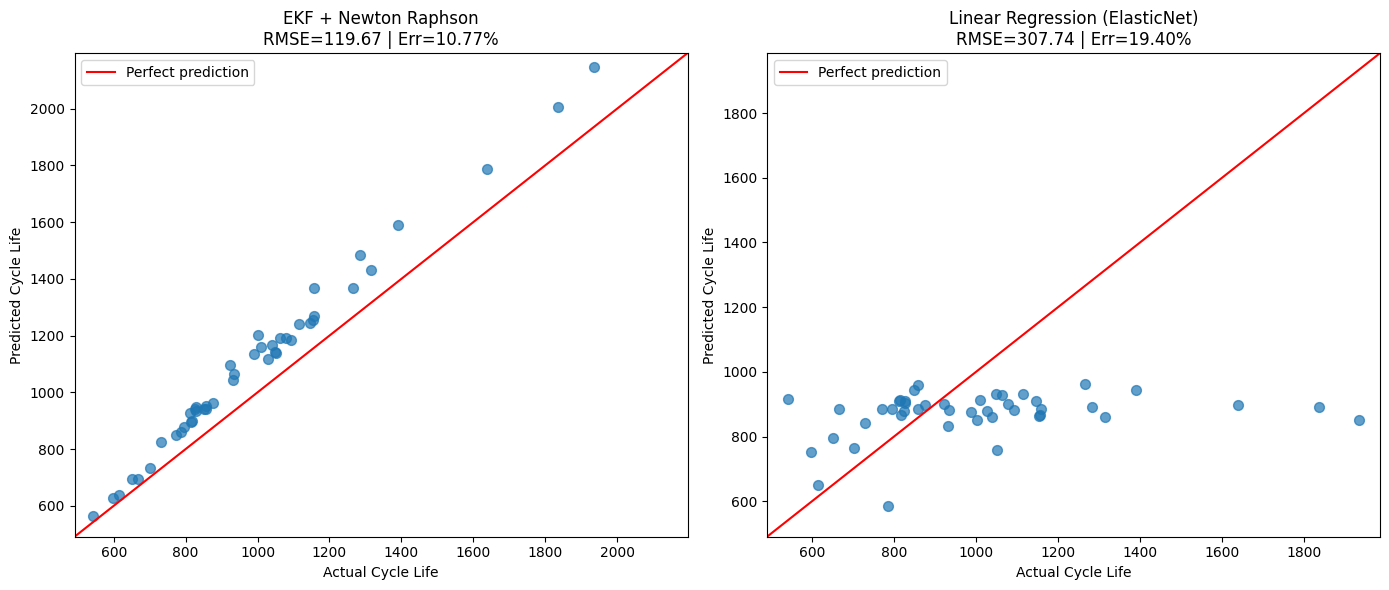

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pairs = [
    (actual_ekfnr, predicted_ekfnr, 'EKF + Newton Raphson'),
    (actual_lr,    predicted_lr,    'Linear Regression (ElasticNet)'),
]

for ax, (actual, predicted, title) in zip(axes, pairs):
    mask = ~np.isnan(predicted)
    a, p = actual[mask], predicted[mask]
    lims = [min(a.min(), p.min()) - 50, max(a.max(), p.max()) + 50]
    ax.plot(lims, lims, 'r-', linewidth=1.5, label='Perfect prediction')
    ax.scatter(a, p, alpha=0.7, s=50)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual Cycle Life')
    ax.set_ylabel('Predicted Cycle Life')
    ax.set_title(f'{title}\nRMSE={rmse(actual, predicted):.2f} | Err={avg_pct_error(actual, predicted):.2f}%')
    ax.legend()

plt.tight_layout()
os.makedirs(os.path.join(OUTPUT_DIR, 'figures'), exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', 'actual_vs_predicted_v1.png'), dpi=150)
plt.show()

## 9. Visualisasi — Per Cell (Fig. 6 paper)

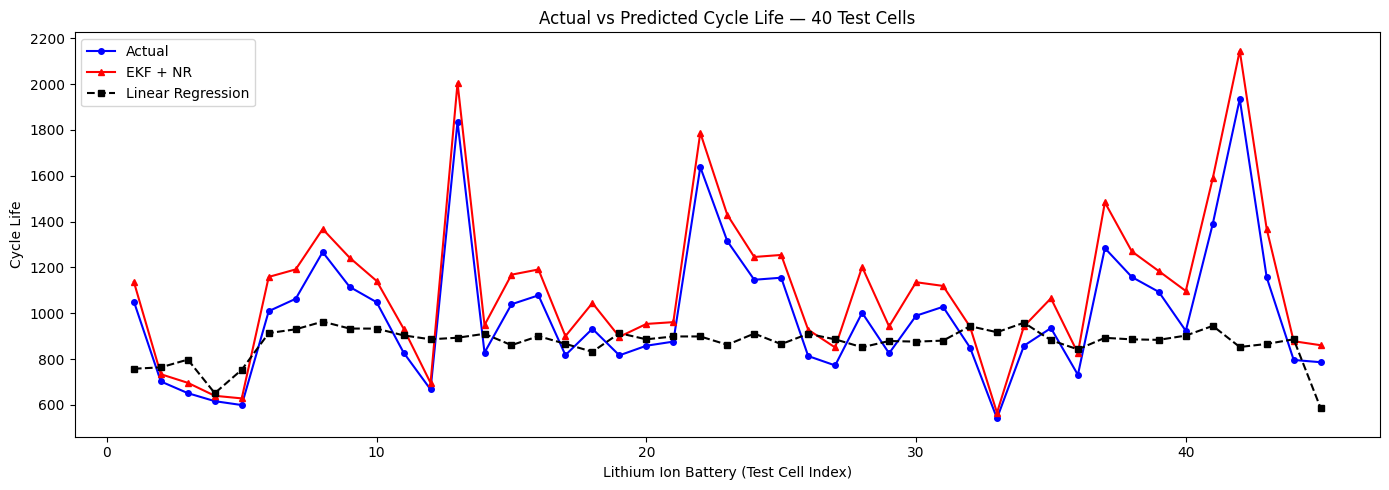

In [11]:
x_idx = np.arange(1, len(actual_ekfnr) + 1)

plt.figure(figsize=(14, 5))
plt.plot(x_idx, actual_ekfnr,    'b-o',  markersize=4, label='Actual')
plt.plot(x_idx, predicted_ekfnr, 'r-^',  markersize=4, label='EKF + NR')
plt.plot(x_idx, predicted_lr,    'k--s', markersize=4, label='Linear Regression')
plt.xlabel('Lithium Ion Battery (Test Cell Index)')
plt.ylabel('Cycle Life')
plt.title('Actual vs Predicted Cycle Life — 40 Test Cells')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', 'per_cell_comparison_v1.png'), dpi=150)
plt.show()

## 10. Simpan Hasil

In [12]:
results = {
    'ekf_nr': {
        'actual':        actual_ekfnr.tolist(),
        'predicted':     predicted_ekfnr.tolist(),
        'rmse':          rmse_ekfnr,
        'avg_pct_error': ape_ekfnr,
    },
    'linear_regression': {
        'actual':        actual_lr.tolist(),
        'predicted':     predicted_lr.tolist(),
        'rmse':          rmse_lr,
        'avg_pct_error': ape_lr,
    }
}

os.makedirs(os.path.join(OUTPUT_DIR, 'results'), exist_ok=True)
with open(os.path.join(OUTPUT_DIR, 'results', 'results_v1.pkl'), 'wb') as f:
    pickle.dump(results, f)

print('Results saved.')
print(f'\nFinal Summary:')
print(f'  EKF+NR  → RMSE: {rmse_ekfnr:.4f} | Avg%Err: {ape_ekfnr:.4f}%')
print(f'  LinReg  → RMSE: {rmse_lr:.4f} | Avg%Err: {ape_lr:.4f}%')

Results saved.

Final Summary:
  EKF+NR  → RMSE: 119.6687 | Avg%Err: 10.7726%
  LinReg  → RMSE: 307.7389 | Avg%Err: 19.3970%
